## Крива прогріву ґрунтового сенсора

Скільки насправді треба чекати після подачі живлення, перш ніж показанню можна довіряти? (зараз у прошивці стоїть груба оцінка **SOIL_WARMUP_MS = 3000**

**Прогрів** - це найдорожча частина циклу по батереї **(~72% часу неспання**), тож заміряне число замість оцінки = місяці різниці в ресурсах.

*Дані: 795 рядків ms, raw, 1 крок = 25мс, два прогони по 10с, прошивка **v2_soilprobe** (soil_warmup_curve.csv)*


In [3]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

path = Path("data/soil_warmup_curve.csv")
df = pd.read_csv(path)

df["ms"] = pd.to_numeric(df["ms"], errors="coerce")
df["raw"] = pd.to_numeric(df["raw"], errors="coerce")

df = df.dropna()

df["ms"] = df["ms"].astype(int)
df["raw"] = df["raw"].astype(int)

print(df.head())
print(df.dtypes)

    ms   raw
0   31  1483
1   57  1963
2   82  2205
3  107  2340
4  132  2421
ms     int64
raw    int64
dtype: object


In [5]:
ms_diff = df["ms"].diff() < 0
df["run_id"] = ms_diff.cumsum()

print(df.groupby("run_id").size())

run_id
0    399
1    396
dtype: int64


In [6]:
plateau = (df[df["ms"] > 5000].groupby("run_id"))["raw"].median()
print(plateau)

run_id
0    2587.0
1    2586.0
Name: raw, dtype: float64


In [10]:
df["plateau"] = df["run_id"].map(plateau)
df["dev"] = df["raw"] - df["plateau"]

print(df.head())

    ms   raw  run_id  plateau     dev
0   31  1483       0   2587.0 -1104.0
1   57  1963       0   2587.0  -624.0
2   82  2205       0   2587.0  -382.0
3  107  2340       0   2587.0  -247.0
4  132  2421       0   2587.0  -166.0


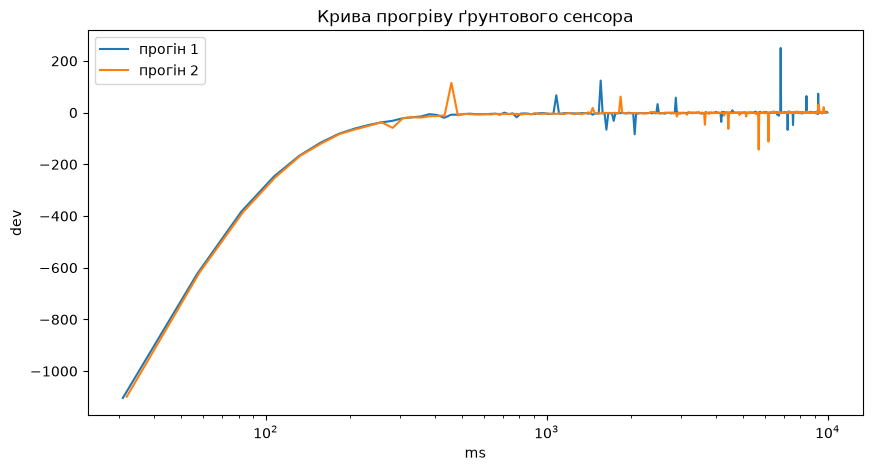

In [12]:
plt.figure(figsize=(10, 5))

run0 = df[df["run_id"] == 0]
run1 = df[df["run_id"] == 1]

plt.plot(run0["ms"], run0["dev"], label="прогін 1")
plt.plot(run1["ms"], run1["dev"], label="прогін 2")

plt.xscale("log")
plt.xlabel("ms")
plt.ylabel("dev")
plt.title("Крива прогріву ґрунтового сенсора")
plt.legend()
plt.show()


In [15]:
import numpy as np

seg0 = run0[run0["ms"] < 300]

log_dev0 = np.log(np.abs(seg0["dev"]))

slope0, intercept0 = np.polyfit(seg0["ms"], log_dev0, 1)
tau0 = -1 / slope0
print(f"τ прогін 0: {tau0:.1f} мс")

seg1 = run1[run1["ms"] < 300]
log_dev1 = np.log(np.abs(seg1["dev"]))

slope1, intercept1 = np.polyfit(seg1["ms"], log_dev1, 1)
tau1 = -1 / slope1
print(f"τ прогін 1: {tau1:.1f} мс")


τ прогін 0: 71.4 мс
τ прогін 1: 77.9 мс


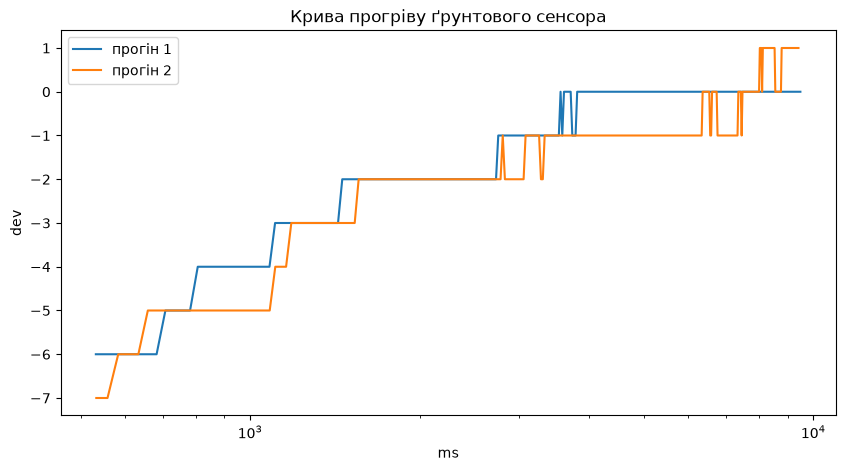

In [19]:
run0_smooth = run0["dev"].rolling(41, center=True).median()
run1_smooth = run1["dev"].rolling(41, center=True).median()

plt.figure(figsize=(10, 5))

run0 = df[df["run_id"] == 0]
run1 = df[df["run_id"] == 1]

plt.plot(run0["ms"], run0_smooth, label="прогін 1")
plt.plot(run1["ms"], run1_smooth, label="прогін 2")

plt.xscale("log")
plt.xlabel("ms")
plt.ylabel("dev")
plt.title("Крива прогріву ґрунтового сенсора")
plt.legend()
plt.show()

In [21]:
thresholds = [5, 1.74, 1.38]
runs = {0: (run0, run0_smooth), 1: (run1, run1_smooth)}

rows = []
for run_id, (run, smooth) in runs.items():
    for t in thresholds:
        bad = smooth.abs() > t
        last_bad_idx = bad[bad].index[-1]
        settle_ms = run.loc[last_bad_idx, "ms"] + 25
        rows.append({"run_id": run_id, "threshold": t, "settle_ms": settle_ms})

settle_table = pd.DataFrame(rows)
print(settle_table)

   run_id  threshold  settle_ms
0       0       5.00        707
1       0       1.74       2757
2       0       1.38       2757
3       1       5.00        658
4       1       1.74       3333
5       1       1.38       3333


### Висновок

**Що зробили:** розбили файл на 2 прогони (`ms.diff() < 0` → `cumsum`),
порахували плато (медіана `raw` при `ms > 5000`), відхилення `dev = raw − plateau`,
і подивились криву `dev(ms)` на логарифмічній осі.

**Формули:**
- Стала часу: модель `dev = A·e^(−t/τ)`, лінеаризована логарифмом:
  `ln|dev| = ln|A| − t/τ` → пряма, нахил якої дає `τ = −1/slope`
  (підгонка `np.polyfit` на ділянці спаду `ms < 300`).
- Шумова смуга ±1.74 — з ноутбука 01 (`diff().std()/√2`),
  смуга ±1.38 — з ноутбука 02 (медіана зміни за 15 хв).

**Чому згладжування вікном 41, а не 5:** пороги 1.74 і 1.38 менші за шум
окремої точки (±2–3), тому питати «чи точка в смузі» безглуздо - вона вискакує
випадково завжди. Питаємо про **зсув** (середній рівень кривої): ковзна медіана
на 41 точку (~1 с) гасить шум і лишає зсув. З вікном 5 критерій упирався у
власний шум і давав безглузді ~9.4 с.

**Результат:** прогрів двомасштабний — швидкий стрибок (τ ≈ 71–78 мс, 95% шляху
за ~225 мс) плюс повільний хвіст у кілька одиниць ADC. Зсув падає нижче 1.38 за
**2757 мс** (прогін 0) / **3333 мс** (прогін 1) → у повітрі `SOIL_WARMUP_MS = 3000`
виправдане.

**Межа:** замір у повітрі — це верхня оцінка; у ґрунті сенсор виходить ~втричі
швидше (польові дані), очікуване бойове число **~1 с**. Фінал — з прогону зі
щупом у ґрунті; ноутбук перезапускається на нових даних без змін.